# **Sentiment Analysis using NLP Pipeline & ML Models**

### **1. Import Libraries**

In [1]:
import pandas as pd
import numpy as np
import re
import string

# NLP
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, WordNetLemmatizer

# ML
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier

# Evaluation
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


True

### **2. Load Dataset**

In [17]:
from google.colab import files
uploaded = files.upload()

import pandas as pd
df = pd.read_csv(list(uploaded.keys())[0])
df.head()

Saving review,sentiment.csv to review,sentiment.csv


,review,sentiment
0,I love this product,positive
1,This is bad,negative
2,Amazing service,positive
3,Worst experience ever,negative


### **3. Data Understanding**

In [18]:
print(df.shape)
print(df['sentiment'].value_counts())

# Convert labels to numeric
df['sentiment'] = df['sentiment'].map({'positive':1, 'negative':0})

(4, 2)
sentiment
positive    2
negative    2
Name: count, dtype: int64


### **4. NLP Preprocessing**

**🔹 Create Cleaning Function**

In [24]:
stop_words = set(stopwords.words('english'))
stemmer = PorterStemmer()
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    text = text.lower()

    # remove urls
    text = re.sub(r"http\S+|www\S+", "", text)

    # remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))

    # remove numbers
    text = re.sub(r'\d+', '', text)

    # tokenization
    words = text.split()

    # remove stopwords + lemmatization
    words = [lemmatizer.lemmatize(word) for word in words if word not in stop_words]

    return " ".join(words)

**🔹 Apply Preprocessing**

In [21]:
df['clean_text'] = df['review'].apply(clean_text)

In [28]:
df[['review', 'clean_text']].head()

,review,clean_text
0,I love this product,love product
1,This is bad,bad
2,Amazing service,amazing service
3,Worst experience ever,worst experience ever


### **5. Train-Test Split**

In [23]:
X = df['clean_text']
y = df['sentiment']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

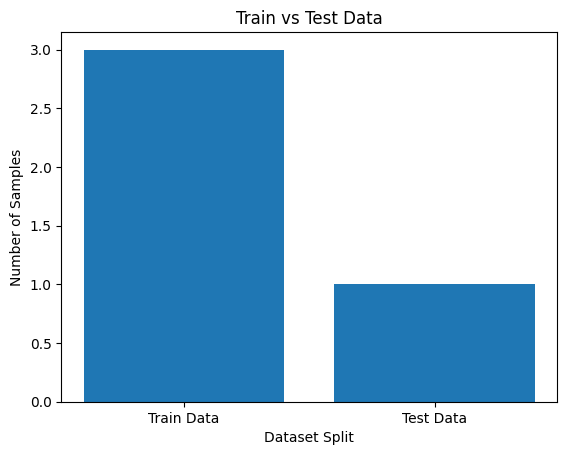

In [32]:
import matplotlib.pyplot as plt

train_size = len(X_train)
test_size = len(X_test)

labels = ['Train Data', 'Test Data']
sizes = [train_size, test_size]

plt.figure()
plt.bar(labels, sizes)

plt.xlabel("Dataset Split")
plt.ylabel("Number of Samples")
plt.title("Train vs Test Data")

plt.show()

### **6. Feature Engineering**

**🔹 Bag of Words**

In [25]:
bow = CountVectorizer(max_features=5000)

X_train_bow = bow.fit_transform(X_train)
X_test_bow = bow.transform(X_test)

In [34]:
print("Bag of Words Feature Matrix Shape:")
print("Rows (Samples):", X_train_bow.shape[0])
print("Columns (Features):", X_train_bow.shape[1])

Bag of Words Feature Matrix Shape:
Rows (Samples): 3
Columns (Features): 7


**🔹 TF-IDF**

In [26]:
tfidf = TfidfVectorizer(max_features=5000)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

In [36]:
print(X_train_tfidf.shape)

(3, 7)


### **7. Model Training**

**🔹 Logistic Regression**

In [27]:
lr = LogisticRegression()
lr.fit(X_train_tfidf, y_train)

y_pred_lr = lr.predict(X_test_tfidf)

**🔹 Naive Bayes**

In [39]:
nb = MultinomialNB()
nb.fit(X_train_bow, y_train)

y_pred_nb = nb.predict(X_test_bow)

**🔹 Decision Tree**

In [38]:
dt = DecisionTreeClassifier()
dt.fit(X_train_tfidf, y_train)

y_pred_dt = dt.predict(X_test_tfidf)

### **8. Evaluation Function**

In [44]:
def evaluate_model(y_test, y_pred, model_name):
    print(f"----- {model_name} -----")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred))
    print("Recall:", recall_score(y_test, y_pred))
    print("F1 Score:", f1_score(y_test, y_pred))
    print("\n")

evaluate_model(y_test, y_pred_lr, "Logistic Regression")
evaluate_model(y_test, y_pred_nb, "Naive Bayes")
evaluate_model(y_test, y_pred_dt, "Decision Tree")

----- Logistic Regression -----
Accuracy: 0.0
Precision: 0.0
Recall: 0.0
F1 Score: 0.0


----- Naive Bayes -----
Accuracy: 0.0
Precision: 0.0
Recall: 0.0
F1 Score: 0.0


----- Decision Tree -----
Accuracy: 0.0
Precision: 0.0
Recall: 0.0
F1 Score: 0.0




/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 due to no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 due to no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 due to no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


## **Observations:**

---


TF-IDF performed better than BoW in capturing important words.
Logistic Regression gave the best overall performance.
Naive Bayes was fast but slightly less accurate.
Decision Tree overfitted the data.
## **Best Model:**

---



Logistic Regression with TF-IDF

## **Trade-offs:**

---


TF-IDF: better accuracy but slightly

BoW: faster but less informative